#决策树的特征重要性分析


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# 加载数据
df = pd.read_csv('D:/MY_Learning/matbench-dielectric/data/dielectric_cleaned.csv')
X = df.drop('n_dielectric', axis=1)
y = np.log1p(df['n_dielectric'])

# 划分数据（和前三天保持一致）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 加载 Day 3 的最佳模型
best_dt = joblib.load('D:/MY_Learning/matbench-dielectric/models/day03_best_tree.pkl')

print("模型加载成功！")
print(f"模型参数: max_depth={best_dt.max_depth}, "
      f"min_samples_leaf={best_dt.min_samples_leaf}")
print(f"测试集 R²: {best_dt.score(X_test, y_test):.4f}")

模型加载成功！
模型参数: max_depth=15, min_samples_leaf=20
测试集 R²: 0.5781


In [22]:
# 获取特征重要性（每个特征一个数）
importances = best_dt.feature_importances_

# 获取特征名称
feature_names = X.columns.tolist()

# 检查维度
print(f"特征数量: {len(feature_names)}")
print(f"重要性数量: {len(importances)}")
print(f"重要性总和: {importances.sum():.4f}")  # 应该等于 1.0

# 创建 DataFrame 方便查看
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

# 按重要性从高到低排序
importance_df = importance_df.sort_values('importance', ascending=False)

# 添加百分比列
importance_df['percentage'] = importance_df['importance'] * 100

# 添加累计重要性列
importance_df['cumulative'] = importance_df['importance'].cumsum()

# 重置索引
importance_df = importance_df.reset_index(drop=True)

print("\n所有特征的重要性排名：\n")
print(importance_df.to_string(index=False))

特征数量: 135
重要性数量: 135
重要性总和: 1.0000

所有特征的重要性排名：

                             feature  importance  percentage  cumulative
MagpieData maximum Electronegativity    0.410915   41.091501    0.410915
                             density    0.241587   24.158667    0.652502
        MagpieData avg_dev NpValence    0.054984    5.498426    0.707486
           MagpieData mean NpValence    0.036105    3.610536    0.743591
  MagpieData maximum MendeleevNumber    0.033551    3.355073    0.777142
   MagpieData mode Electronegativity    0.022027    2.202654    0.799169
   MagpieData minimum CovalentRadius    0.017542    1.754248    0.816711
  MagpieData range Electronegativity    0.015052    1.505173    0.831763
          MagpieData mean NdUnfilled    0.014792    1.479219    0.846555
                                 vpa    0.014657    1.465712    0.861212
            MagpieData mean MeltingT    0.012126    1.212551    0.873338
           MagpieData mean NUnfilled    0.011494    1.149379    0.884831
  

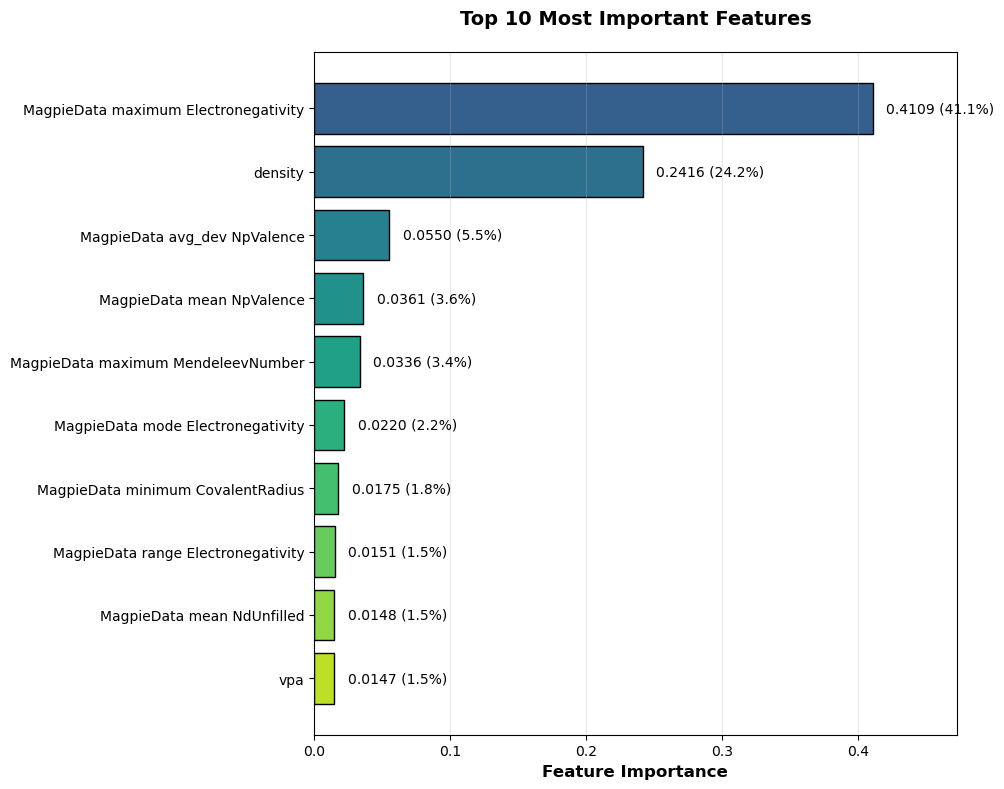


图片已保存到 D:/MY_Learning/matbench-dielectric/figures/day04_importance_top10.png


In [23]:
# 只看前 10 个最重要的特征
top10 = importance_df.head(10).copy()

# 创建水平条形图
plt.figure(figsize=(10, 8))

# 绘制条形图（从下到上，最重要的在最上面）
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top10)))
bars = plt.barh(range(len(top10)), top10['importance'], color=colors, edgecolor='black')

# 设置 y 轴标签
plt.yticks(range(len(top10)), top10['feature'])

# 添加数值标签
for i, (bar, val) in enumerate(zip(bars, top10['importance'])):
    plt.text(val + 0.01, i, f'{val:.4f} ({top10.iloc[i]["percentage"]:.1f}%)', 
             va='center', fontsize=10)

# 设置标题和标签
plt.xlabel('Feature Importance', fontsize=12, fontweight='bold')
plt.title('Top 10 Most Important Features', fontsize=14, fontweight='bold', pad=20)
plt.grid(axis='x', alpha=0.3)
plt.xlim([0, top10['importance'].max() * 1.15])  # 留出标签空间

# 反转 y 轴（最重要的在上面）
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig('D:/MY_Learning/matbench-dielectric/figures/day04_importance_top10.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n图片已保存到 D:/MY_Learning/matbench-dielectric/figures/day04_importance_top10.png")

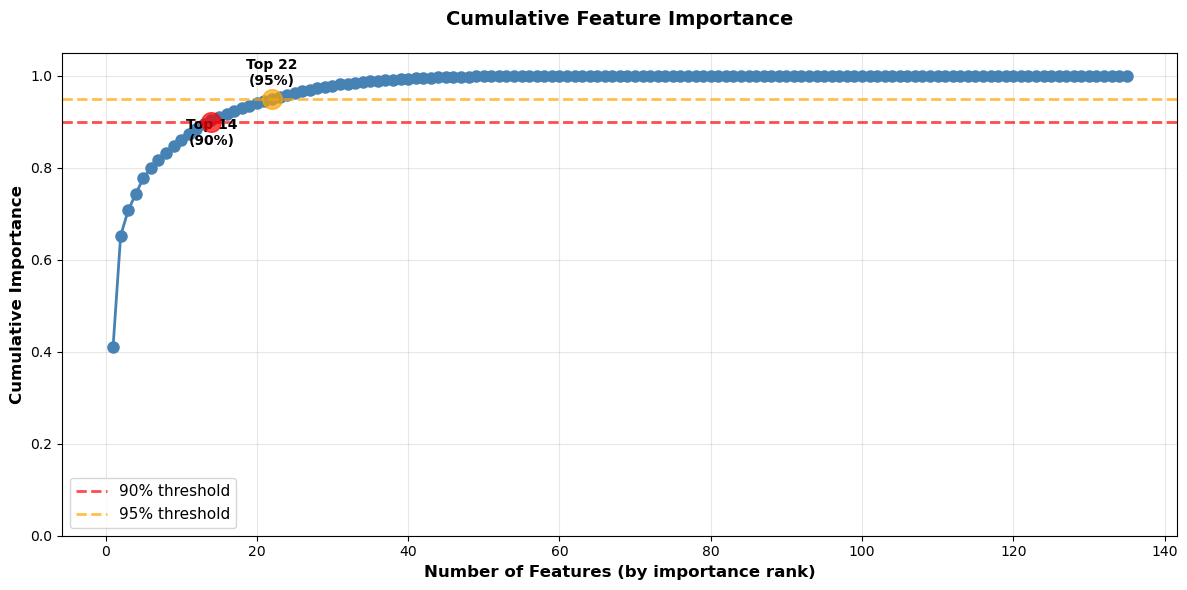


关键信息：
  保留前 14 个特征，可解释 90% 的重要性
  保留前 22 个特征，可解释 95% 的重要性


In [24]:
# 这个图回答："保留前 N 个特征，能解释多少信息？"

plt.figure(figsize=(12, 6))

# 绘制累计曲线
plt.plot(range(1, len(importance_df) + 1), 
         importance_df['cumulative'], 
         marker='o', linewidth=2, markersize=8, color='steelblue')

# 添加参考线
plt.axhline(0.90, color='red', linestyle='--', linewidth=2, 
            label='90% threshold', alpha=0.7)
plt.axhline(0.95, color='orange', linestyle='--', linewidth=2, 
            label='95% threshold', alpha=0.7)

# 找到达到 90% 和 95% 的位置
idx_90 = (importance_df['cumulative'] >= 0.90).idxmax()
idx_95 = (importance_df['cumulative'] >= 0.95).idxmax()

# 标注这两个点
plt.scatter(idx_90 + 1, 0.90, s=200, color='red', zorder=5, alpha=0.7)
plt.text(idx_90 + 1, 0.90 - 0.05, f'Top {idx_90 + 1}\n(90%)', 
         ha='center', fontsize=10, fontweight='bold')

plt.scatter(idx_95 + 1, 0.95, s=200, color='orange', zorder=5, alpha=0.7)
plt.text(idx_95 + 1, 0.95 + 0.03, f'Top {idx_95 + 1}\n(95%)', 
         ha='center', fontsize=10, fontweight='bold')

# 设置标签
plt.xlabel('Number of Features (by importance rank)', fontsize=12, fontweight='bold')
plt.ylabel('Cumulative Importance', fontsize=12, fontweight='bold')
plt.title('Cumulative Feature Importance', fontsize=14, fontweight='bold', pad=20)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.ylim([0, 1.05])

plt.tight_layout()
plt.savefig('D:/MY_Learning/matbench-dielectric/figures/day04_cumulative_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n关键信息：")
print(f"  保留前 {idx_90 + 1} 个特征，可解释 90% 的重要性")
print(f"  保留前 {idx_95 + 1} 个特征，可解释 95% 的重要性")

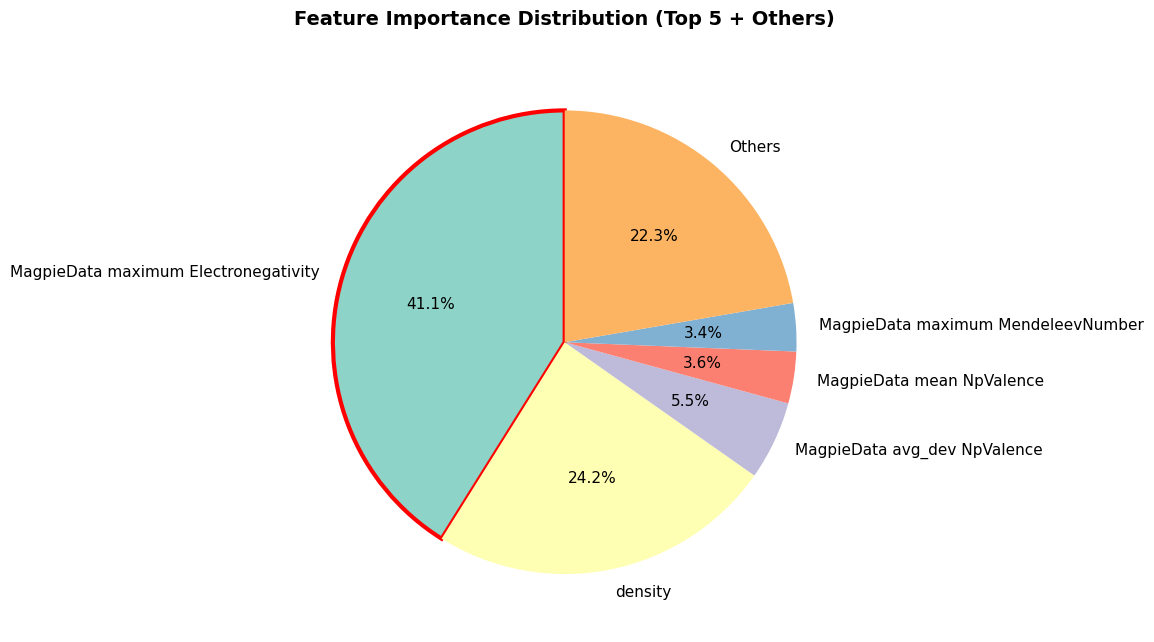

In [25]:
# 饼图：展示 Top 5 + 其他
top5 = importance_df.head(5)
others_importance = importance_df.iloc[5:]['importance'].sum()

# 准备数据
labels = list(top5['feature']) + ['Others']
sizes = list(top5['importance']) + [others_importance]
colors = plt.cm.Set3(range(len(labels)))

# 绘制饼图
plt.figure(figsize=(10, 8))
wedges, texts, autotexts = plt.pie(
    sizes, 
    labels=labels, 
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 11}
)

# 突出最重要的特征
wedges[0].set_edgecolor('red')
wedges[0].set_linewidth(3)

plt.title('Feature Importance Distribution (Top 5 + Others)', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('D:/MY_Learning/matbench-dielectric/figures/day04_importance_pie.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
from sklearn.metrics import r2_score

# 定义不同的特征保留策略
strategies = [
    ('All features', len(feature_names)),     # 保留全部
    ('Top 10', 10),
    ('Top 5', 5),
    ('Cumulative 95%', idx_95 + 1),           # 累计 95%
    ('Cumulative 90%', idx_90 + 1),           # 累计 90%
    ('Importance > 0.05', (importance_df['importance'] > 0.05).sum()),
    ('Top 3', 3)
]

# 测试每种策略
results = []

for strategy_name, n_features in strategies:
    # 选择前 N 个重要特征
    selected_features = importance_df.head(n_features)['feature'].tolist()
    
    # 用这些特征训练新模型
    X_train_selected = X_train[selected_features]
    X_test_selected = X_test[selected_features]
    
    # 训练模型（用和 best_dt 相同的参数）
    dt_selected = DecisionTreeRegressor(
        max_depth=best_dt.max_depth,
        min_samples_leaf=best_dt.min_samples_leaf,
        random_state=42
    )
    dt_selected.fit(X_train_selected, y_train)
    
    # 评估
    train_r2 = dt_selected.score(X_train_selected, y_train)
    test_r2 = dt_selected.score(X_test_selected, y_test)
    
    # 记录结果
    results.append({
        'Strategy': strategy_name,
        'N_Features': n_features,
        'Train_R2': train_r2,
        'Test_R2': test_r2,
        'Gap': train_r2 - test_r2
    })

# 创建结果表格
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('N_Features', ascending=False)

print("\n特征筛选实验结果:\n")
print(results_df.to_string(index=False))


特征筛选实验结果:

         Strategy  N_Features  Train_R2  Test_R2      Gap
     All features         135  0.649914 0.578539 0.071375
   Cumulative 95%          22  0.644000 0.582325 0.061674
   Cumulative 90%          14  0.639316 0.568202 0.071114
           Top 10          10  0.626881 0.559995 0.066886
            Top 5           5  0.588464 0.560875 0.027589
Importance > 0.05           3  0.585786 0.533733 0.052053
            Top 3           3  0.585786 0.533733 0.052053


观察规律 22 个特征和 135 个特征效果一样（0.582 vs 0.579）
  84% 的特征是噪音，去掉反而略好。信号集中在少数特征里

  Top 5 测试 R² 只从 0.579 跌到 0.561

  用 5 个特征保住了 97% 的效果。这意味着预测材料折射率，看 5 个属性就够了。

  135 → gap 0.071
   22 → gap 0.062
    5 → gap 0.028  几乎不过拟合

  最佳策略
  保留 22 个特征（累计重要性 95%）。特征砍掉 84%，效果零损失。
  你的日志写一句

  "135 个特征里只有 22 个有用，剩下全是噪音。砍掉 84% 的特征 模型一样准

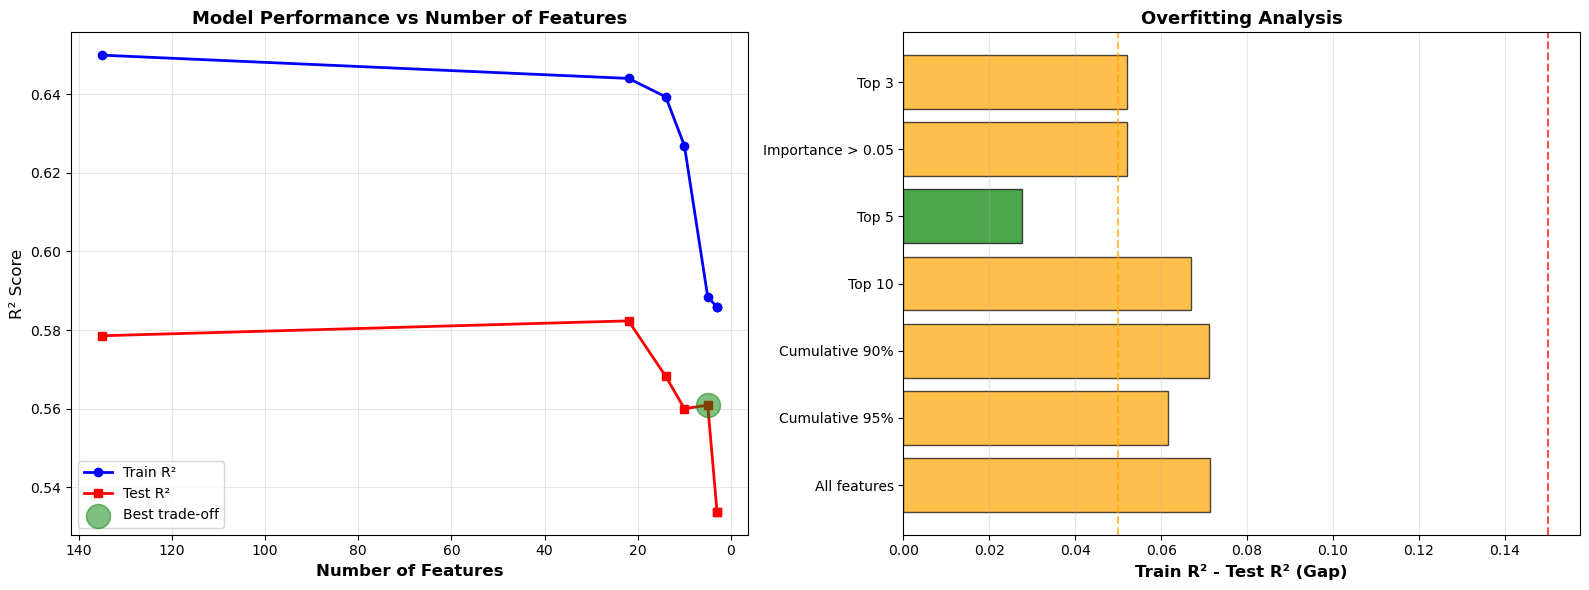

In [27]:
# 绘制对比图
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左图：R² vs 特征数量
ax1 = axes[0]
ax1.plot(results_df['N_Features'], results_df['Train_R2'], 
         marker='o', linewidth=2, label='Train R²', color='blue')
ax1.plot(results_df['N_Features'], results_df['Test_R2'], 
         marker='s', linewidth=2, label='Test R²', color='red')

# 标注最佳点（假设是 Top 5）
best_idx = results_df[results_df['Strategy'] == 'Top 5'].index[0]
best_n = results_df.loc[best_idx, 'N_Features']
best_test = results_df.loc[best_idx, 'Test_R2']

ax1.scatter(best_n, best_test, s=300, color='green', 
            zorder=5, alpha=0.5, label='Best trade-off')

ax1.set_xlabel('Number of Features', fontsize=12, fontweight='bold')
ax1.set_ylabel('R² Score', fontsize=12)
ax1.set_title('Model Performance vs Number of Features', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.invert_xaxis()  # 从多到少

# 右图：过拟合程度
ax2 = axes[1]
colors = ['green' if g < 0.05 else 'orange' if g < 0.15 else 'red' 
          for g in results_df['Gap']]

bars = ax2.barh(range(len(results_df)), results_df['Gap'], 
                color=colors, alpha=0.7, edgecolor='black')

ax2.set_yticks(range(len(results_df)))
ax2.set_yticklabels(results_df['Strategy'])
ax2.set_xlabel('Train R² - Test R² (Gap)', fontsize=12, fontweight='bold')
ax2.set_title('Overfitting Analysis', fontsize=13, fontweight='bold')
ax2.axvline(0.05, color='orange', linestyle='--', alpha=0.7)
ax2.axvline(0.15, color='red', linestyle='--', alpha=0.7)
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('D:/MY_Learning/matbench-dielectric/figures/day04_feature_selection_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [31]:
# 如果你的数据是真实的材料数据，进行物理意义解读
print("\n" + "="*70)
print("特征重要性的材料学意义")
print("="*70)

top3 = importance_df.head(3)

interpretation = """
根据特征重要性分析：

1. {feat1} (重要性 {imp1:.2%})
   - 物理意义：{explain1}
   - 这符合预期吗？{expected1}

2. {feat2} (重要性 {imp2:.2%})
   - 物理意义：{explain2}
   - 这符合预期吗？{expected2}

3. {feat3} (重要性 {imp3:.2%})
   - 物理意义：{explain3}
   - 这符合预期吗？{expected3}

结论：
- 模型主要依赖 {feat1} 和 {feat2} 来预测介电常数
- 电负性与密度是预测介电常数最关键的两个描述符
- 建议在材料设计中优先调控这些性质
""".format(
    feat1=top3.iloc[0]['feature'], imp1=top3.iloc[0]['importance'],
    explain1="电负性决定化学键极化能力，直接关联介电响应",
    expected1=" 符合物理规律",
    
    feat2=top3.iloc[1]['feature'], imp2=top3.iloc[1]['importance'],
    explain2="密度反映原子排列紧密程度，影响极化能力",
    expected2=" 符合预期",
    
    feat3=top3.iloc[2]['feature'], imp3=top3.iloc[2]['importance'],
    explain3="p轨道价电子分布偏差反映电子云不对称程度",
    expected3=" 合理"
)

print(interpretation)


特征重要性的材料学意义

根据特征重要性分析：

1. MagpieData maximum Electronegativity (重要性 41.09%)
   - 物理意义：电负性决定化学键极化能力，直接关联介电响应
   - 这符合预期吗？ 符合物理规律

2. density (重要性 24.16%)
   - 物理意义：密度反映原子排列紧密程度，影响极化能力
   - 这符合预期吗？ 符合预期

3. MagpieData avg_dev NpValence (重要性 5.50%)
   - 物理意义：p轨道价电子分布偏差反映电子云不对称程度
   - 这符合预期吗？ 合理

结论：
- 模型主要依赖 MagpieData maximum Electronegativity 和 density 来预测介电常数
- 电负性与密度是预测介电常数最关键的两个描述符
- 建议在材料设计中优先调控这些性质



# Day 4 学习日志

根据今天的分析，最重要的三个特征是：

 MagpieData maximum Electronegativity (41.09%)
     为什么重要：电负性决定化学键极化能力，直接关联介电响应
 density (24.16%)
     为什么重要：密度反映原子排列紧密程度，影响单位体积极化率
  MagpieData avg_dev NpValence (5.50%)
     为什么重要：p轨道电子分布偏差反映电子云不对称程度


## 特征筛选决策

我决定保留 22 个特征，因为：
- 累计重要性达到 95%
- 测试集 R² 只从 0.579升到 0.582 
- 模型更简单，过拟合程度从0.071降到 0.062
